In [ ]:
# 既にインストールされていれば不要
!pip install stim
!pip install pymatching

In [2]:
import stim
import pymatching
import numpy as np
import matplotlib.pyplot as plt

# グラフのスタイル設定
plt.rcParams['font.size'] = 12

In [3]:
def prepare_circuit(distance, p):
    """
    表面符号のメモリ実験の回路を生成する．
    """
    circuit = stim.Circuit.generated(
        "surface_code:rotated_memory_z",
        distance=distance,
        rounds=distance,
        after_clifford_depolarization=p,
        after_reset_flip_probability=p,
        before_measure_flip_probability=p,
        before_round_data_depolarization=p
    )
    return circuit

def count_logical_errors_surface(distance, p, shots):
    """ 表面符号のメモリ実験を行い，論理エラー数をカウントする．
    """
    # 1. 表面符号のメモリ実験回路生成
    circuit = prepare_circuit(distance, p)

    # 2. デコーダの構築(MWPM)
    model = circuit.detector_error_model(decompose_errors=True)
    matcher = pymatching.Matching.from_detector_error_model(model)

    # 3. サンプリング
    # separate_observables=True を使うことで，
    # detection_events (シンドローム) とactual_observables (論理反転の真値) を分けて取得
    sampler = circuit.compile_detector_sampler()
    detection_events, actual_observables = sampler.sample(
        shots=shots, separate_observables=True
    )

    # 4. 復号(予測)
    # decode_batch で高速に一括処理
    predicted_observables = matcher.decode_batch(detection_events)

    # 5. 判定
    # 予測した論理反転と，実際の論理反転が食い違えばエラー
    # actual_observables は(shots, 1)の形状，predicted_observables も(shots, 1)
    # 形状を合わせるためにreshapeする必要がないか確認しつつ比較
    num_errors = np.sum(np.any(predicted_observables != actual_observables, axis=1))

    return num_errors

# テスト実行
d_test, p_test, shots_test = 3, 0.001, 1000
errors = count_logical_errors_surface(d_test, p_test, shots_test)
print(f"Test run (d={d_test}, p={p_test}): {errors} errors / {shots_test} shots")

Test run (d=3, p=0.001): 1 errors / 1000 shots


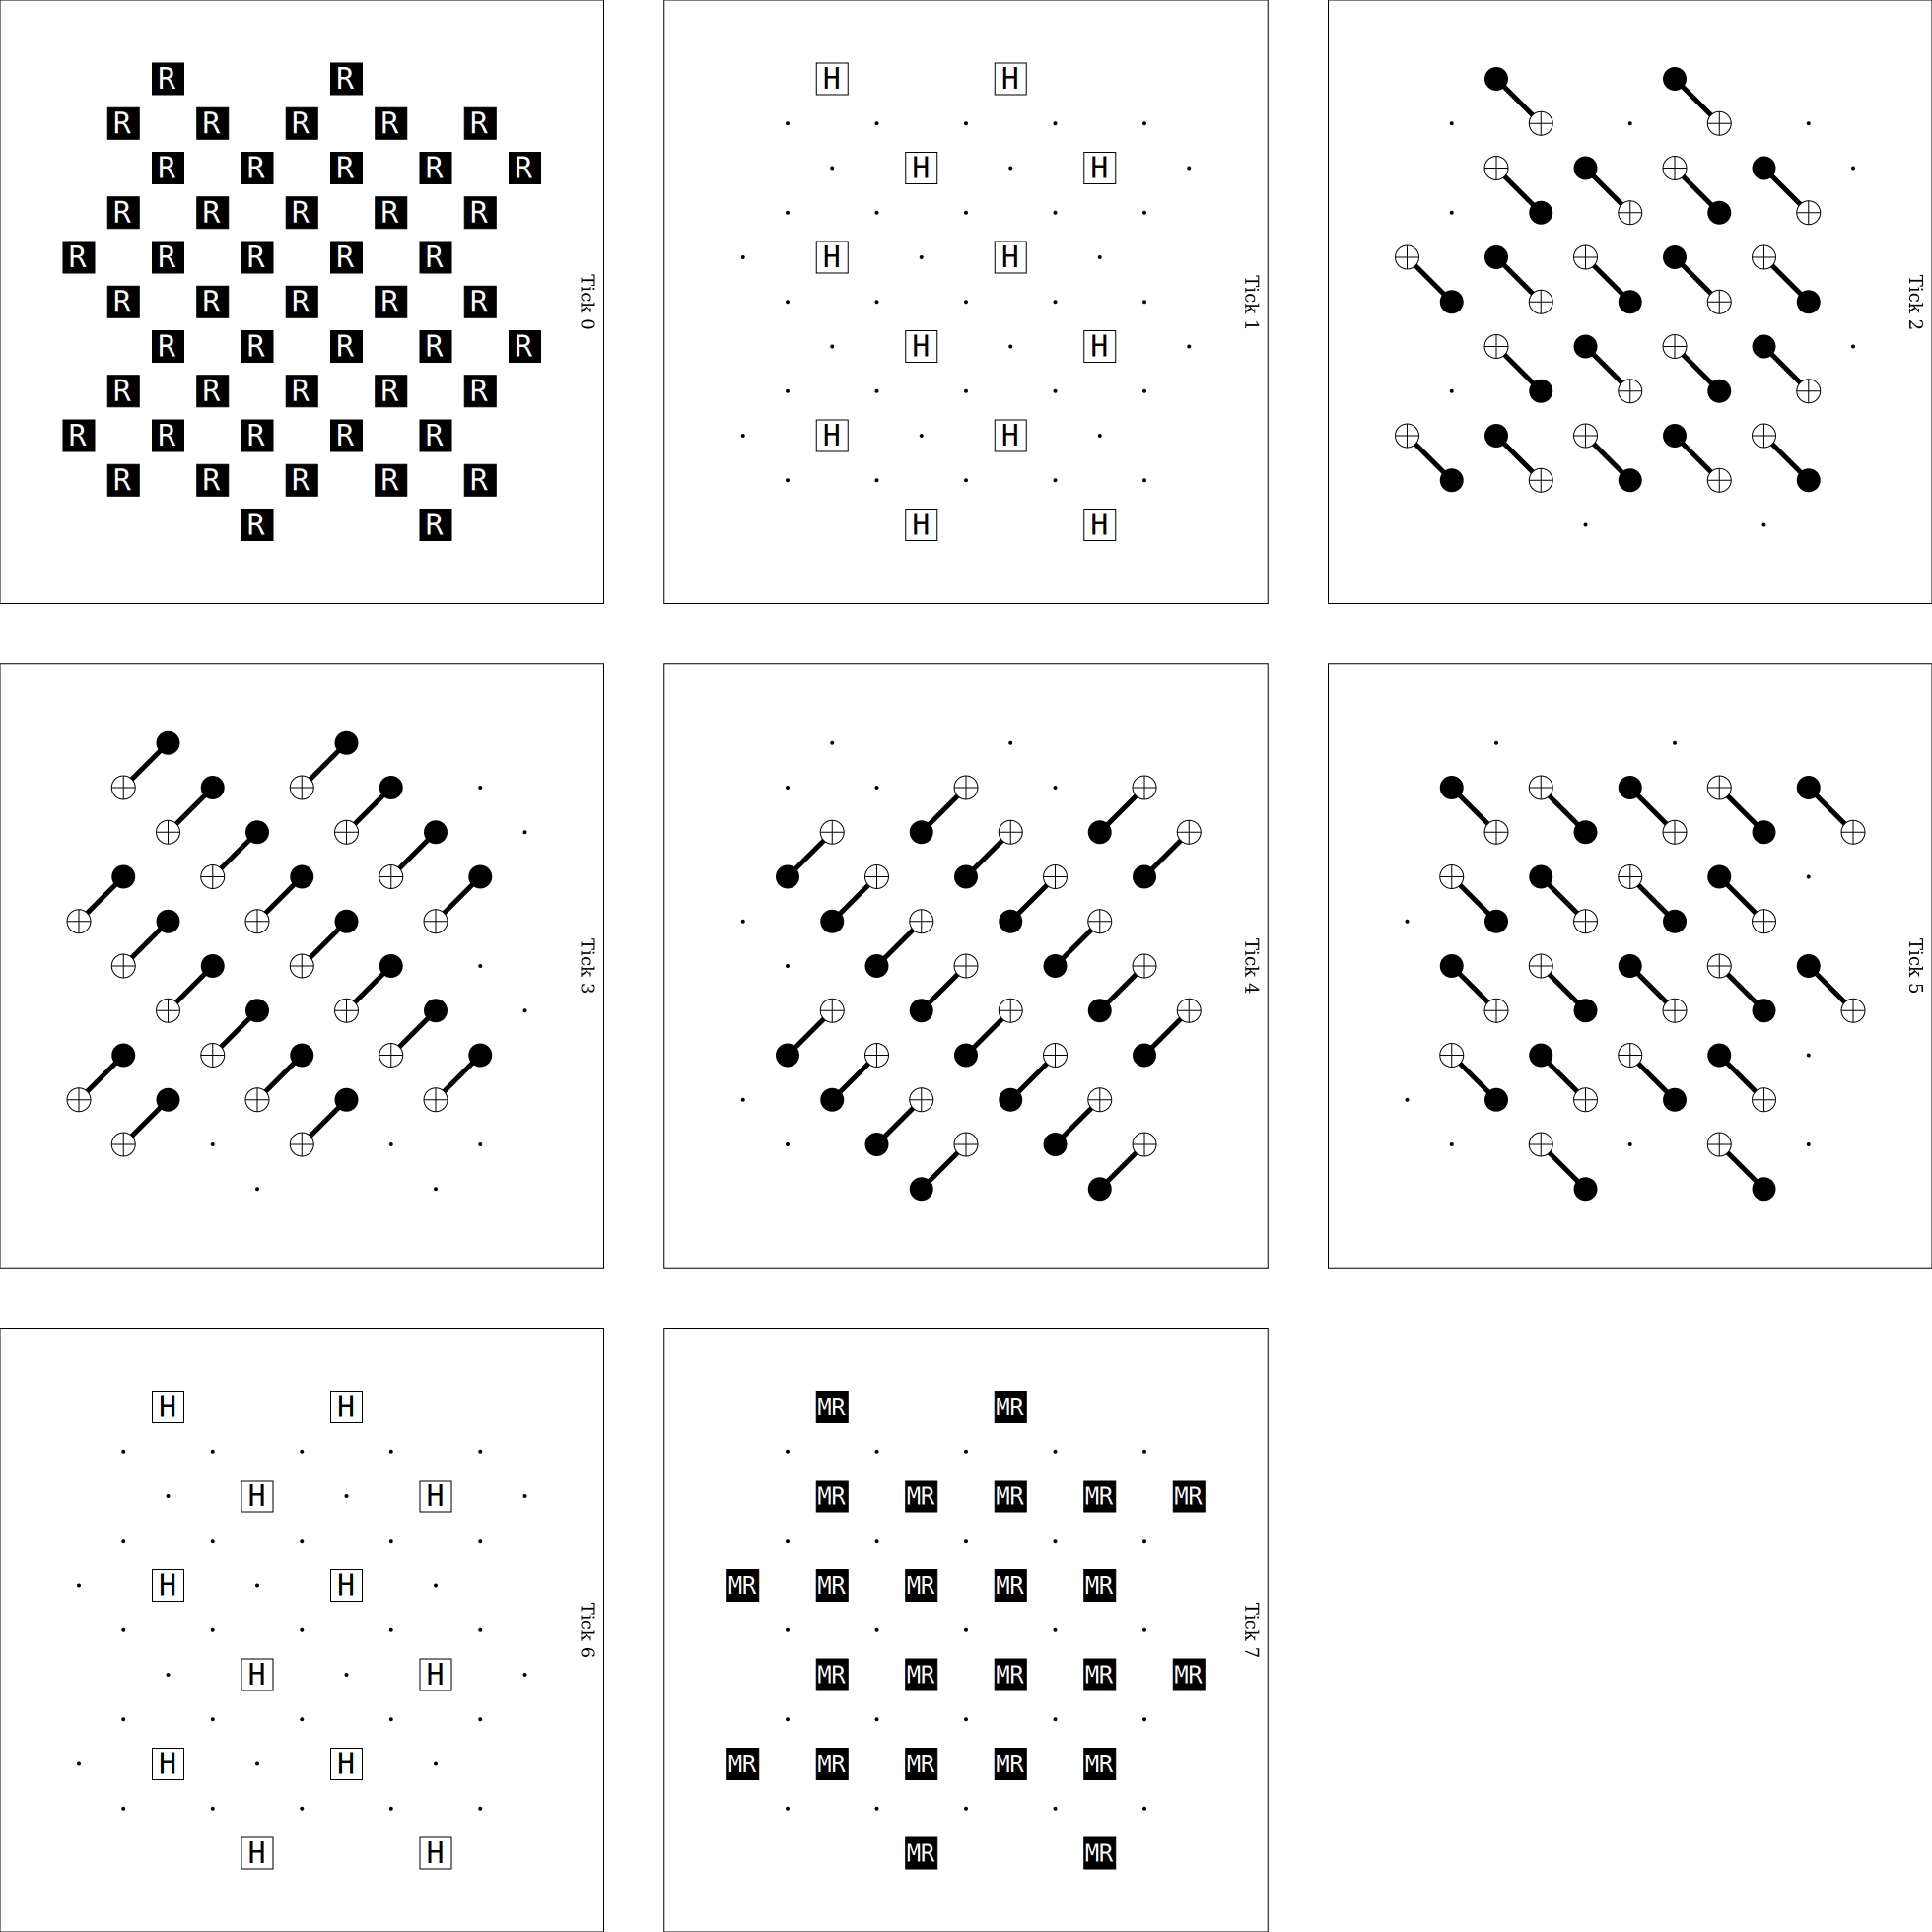

In [4]:
# d = 3 の回路の可視化
# エラー操作を除去した d = 5 の回路
circuit = prepare_circuit(distance=5, p=0).without_noise()
# 繰り返しのシンドローム測定回路の最初の1周期をプロット
circuit.diagram('timeslice-svg', tick=range(0, 8))

Simulating...
Distance 3:
 p=0.0010 -> P_L=0.00078
 p=0.0020 -> P_L=0.00285
 p=0.0030 -> P_L=0.00662
 p=0.0040 -> P_L=0.01122
 p=0.0050 -> P_L=0.01700
 p=0.0060 -> P_L=0.02395
 p=0.0070 -> P_L=0.03184
 p=0.0080 -> P_L=0.04037
 p=0.0090 -> P_L=0.04931
 p=0.0100 -> P_L=0.05904
Distance 5:
 p=0.0010 -> P_L=0.00014
 p=0.0020 -> P_L=0.00100
 p=0.0030 -> P_L=0.00327
 p=0.0040 -> P_L=0.00752
 p=0.0050 -> P_L=0.01380
 p=0.0060 -> P_L=0.02272
 p=0.0070 -> P_L=0.03443
 p=0.0080 -> P_L=0.04871
 p=0.0090 -> P_L=0.06543
 p=0.0100 -> P_L=0.08432
Distance 7:
 p=0.0010 -> P_L=0.00002
 p=0.0020 -> P_L=0.00030
 p=0.0030 -> P_L=0.00137
 p=0.0040 -> P_L=0.00433
 p=0.0050 -> P_L=0.01018
 p=0.0060 -> P_L=0.01930
 p=0.0070 -> P_L=0.03361
 p=0.0080 -> P_L=0.05240
 p=0.0090 -> P_L=0.07585
 p=0.0100 -> P_L=0.10345


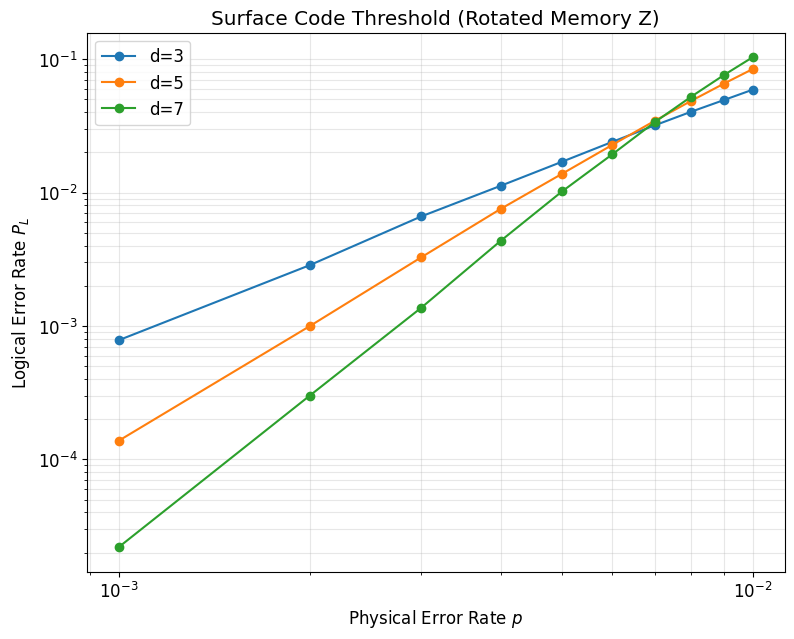

In [5]:
# パラメータ設定
distances = [3, 5, 7]
# しきい値付近(0.003~0.006)を重点的に見るための範囲設定
probs = np.linspace(0.001, 0.01, 10)
shots = 500_000 # 統計精度を上げるために回数を増やす

results = {}

print("Simulating...")
for d in distances:
    errors_list = []
    print(f"Distance {d}:")
    for p in probs:
        num_errors = count_logical_errors_surface(d, p, shots)
        logical_error_rate = num_errors / shots
        errors_list.append(logical_error_rate)
        print(f" p={p:.4f} -> P_L={logical_error_rate:.5f}")
    results[d] = errors_list

# プロット
plt.figure(figsize=(9, 7))
for d in distances:
  plt.plot(probs, results[d], 'o-', label=f"d={d}")

plt.xlabel("Physical Error Rate $p$")
plt.ylabel("Logical Error Rate $P_L$")
plt.title("Surface Code Threshold (Rotated Memory Z)")
plt.loglog()
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()